In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

/home/zequi/miniconda3/lib/python3.11/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.stats import gaussian_kde


In [2]:
df = pd.read_csv("results.csv")

df["tp"] = df["bytes_recv"] / df["time"] / 2**20
df.loc[df["workers"]==101, "package"] = "kerchunk (original NetCDF)"
df.loc[(df["workers"]==100) & (df["package"]=="kerchunk"), "package"] = "kerchunk (repacked NetCDF)"

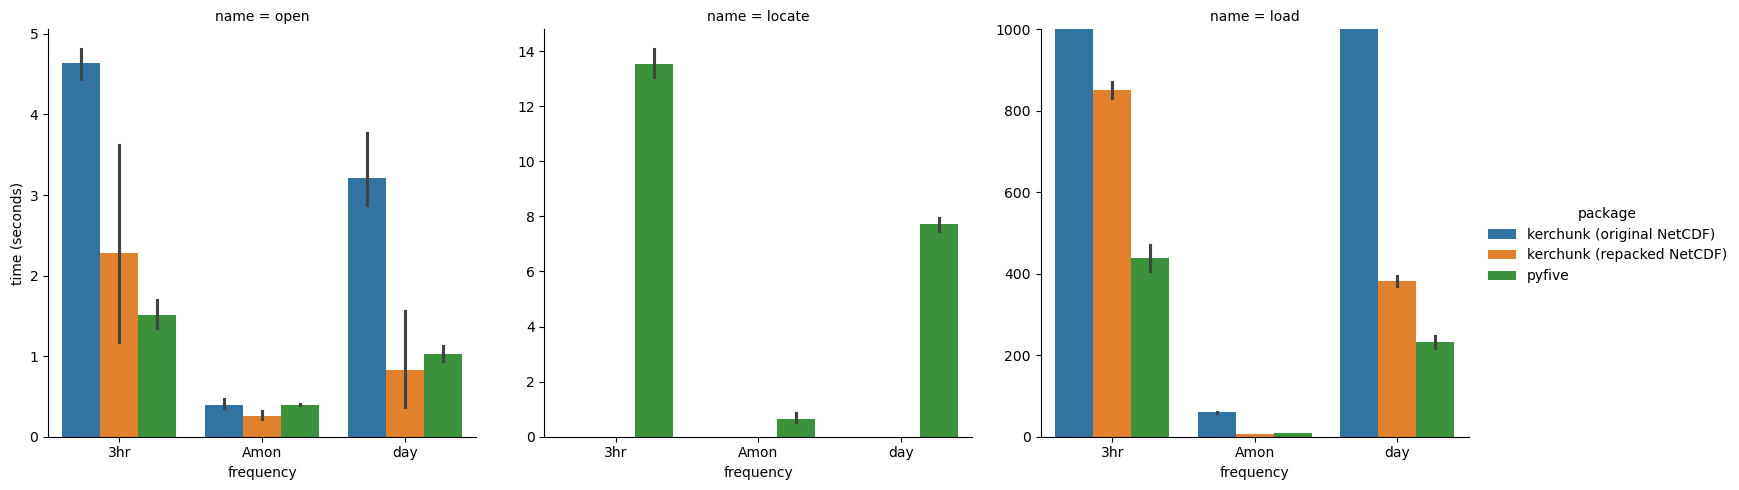

In [3]:
g = seaborn.catplot(
    df, kind="bar",
    x="frequency", y="time", col="name",
    hue="package",
    hue_order=["kerchunk (original NetCDF)", "kerchunk (repacked NetCDF)", "pyfive"],
    sharey=False)
g.axes[0,0].set_ylabel("time (seconds)")
g.axes[0,2].set(ylim=(0, 1000))
g.fig.savefig("test.pdf")

In [4]:
# df = pd.read_csv("results-cr.csv")
# df["tp"] = df["bytes_recv"] / a["time"] / 2**20
# df.loc[df["workers"]==101, "package"] = "kerchunk (original NetCDF)"
# df.loc[(df["workers"]==100) & (df["package"]=="kerchunk"), "package"] = "kerchunk (repacked NetCDF)"
df.loc[(df["workers"]==100) & (df["package"]=="pyfive"), "package"] = "pyfive (repacked NetCDF)"
df.loc[df["name"]=="load","time"] = df.loc[df["name"]=="load","time"] / 60
df = df[~(df["name"]=="locate")]

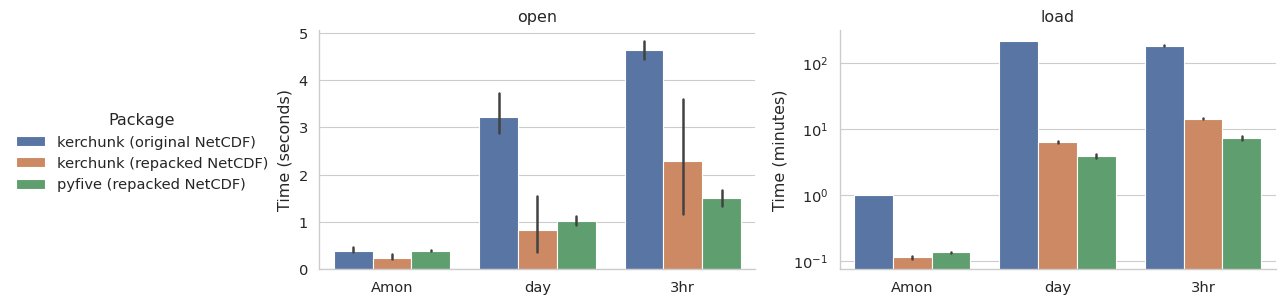

In [5]:
seaborn.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2
)

palette = {
    "kerchunk (original NetCDF)": "#4C72B0",   # muted blue
    "kerchunk (repacked NetCDF)": "#DD8452",   # muted orange
    "pyfive (repacked NetCDF)": "#55A868"      # muted green
}

g = seaborn.catplot(
    data=df,
    kind="bar",
    x="frequency",
    y="time",
    col="name",
    hue="package",
    hue_order=[
        "kerchunk (original NetCDF)",
        "kerchunk (repacked NetCDF)",
        "pyfive (repacked NetCDF)"
    ],
    order=["Amon", "day", "3hr"],
    palette=palette,
    sharey=False,
    height=3.2,
    aspect=1.2,
    legend=True
)

g.set_axis_labels("", "Time (seconds)")
#g.set(yscale="log")
g.axes[0,1].set(yscale="log")
g.axes[0,1].set_ylabel("Time (minutes)")
g.set_titles(col_template="{col_name}")

# Remove top/right spines for a cleaner look
for ax in g.axes.flat:
    seaborn.despine(ax=ax)

seaborn.move_legend(
    g,
    "center left",
    bbox_to_anchor=(-0.25, 0.5),  # tweak this for spacing
    frameon=False,
    title="Package"
)

g.fig.tight_layout()
g.fig.savefig("test.pdf", bbox_inches="tight")